In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import networkx as nx
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

sys.path.insert(1, '../utils')
from sklearn.feature_selection import mutual_info_regression as MI

from utils import * 
from plotUtils import *
from fcMeasure import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
FUNC_MEASURE = {
                'DCOR': r"$\mathcal{S}_{dCorr}$",
                'PLV_LOW': r"$\mathcal{S}_{PLV}^{\,\gamma}$",
                'PLV_HIGH': r"$\mathcal{S}_{PLV}^{\,\rm HFO}$"
}

In [3]:
def sort_filesK(files):
    # sorting based on K value

    Karr = []
    _results = []

    for _file in files:
        basename = os.path.basename(_file).split('.pkl')[0]
        K = float(basename.split('_')[3])

        Karr.append(K)
        _results.append(_file)

    Karr = np.array(Karr)
    _results = np.array(_results)
    
    Ksort = np.argsort(Karr)
    _results = _results[Ksort]

    return _results, Karr[Ksort]

In [4]:
def sort_filesI(files):
    # sorting based on I value

    Iarr = []
    _results = []

    for _file in files:
        basename = os.path.basename(_file).split('.pkl')[0]
        I = float(basename.split('_')[1].split('mV')[0])

        Iarr.append(I)
        _results.append(_file)

    Iarr = np.array(Iarr)
    _results = np.array(_results)

    Isort = np.argsort(Iarr)
    _results = _results[Isort]
 
    return _results, Iarr[Isort]

In [5]:
def get_kfiles(loaddir, seArr, **opts):
    fileDict = {}
    for nse, sige in enumerate(seArr):
        _results = glob.glob(os.path.join(loaddir, f"Imod_{opts['i_mod']:.3f}mV*_sige_{sige:.3f}_sigVar_{opts.get('rho'):.2f}.pkl"))
        print(f"No. of files = {len(_results)}")

        FuncA, Karr = sort_filesK(_results)
        fileDict[sige] = FuncA    
    return fileDict, Karr

def _get_kfiles(loaddir, seArr, siArr, **opts):
    fileDict = {}
    nComb = 0
    for nse, sige in enumerate(seArr):
        for nsi, sigi in enumerate(siArr):
            _results = glob.glob(os.path.join(loaddir, f"Imod_{opts['i_mod']:.3f}mV*_sige_{sige:.3f}_sigi_{sigi:.3f}.pkl"))
            print(f"No. of files = {len(_results)}")

            FuncA, Karr = sort_filesK(_results)
            fileDict[nComb] = FuncA
            nComb += 1
    
    return fileDict, Karr

In [6]:
def deltfweightdist(_rhofiles, _basefiles, sigVar, _sigeArr, _sigiArr, Xarr, Xlabel, figroot, M = 1, **opts):
    COLORS = ["b", "g", "r", "purple"]
    nEdges = int(opts.get("N") * (opts.get("N") - 1) / 2)
    nX = len(Xarr)

    for measure, mText in FUNC_MEASURE.items():
        for rho in sigVar:
            _filename = f"Imod_{opts.get('i_mod'):.3f}mV_{measure}_{M}_sigVar_{rho:2f}.jpg"
            fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8, 4), layout="constrained")
            nROw = 0
            k = 0
            for ne, sige in enumerate(_sigeArr):
                nCol = 0
                for ni, sigi in enumerate(_sigiArr):
                    weightArr = np.zeros((nX, nEdges))

                    for _Kind in range(nX):
                        VFC = pickle.load(open(_rhofiles[rho][sige][_Kind], "rb"))[sigi][measure]
                        BFC = pickle.load(open(_basefiles[k][_Kind], "rb"))[measure]

                        if type(VFC) is list:
                            VFC = np.array(VFC)
                            VFC[np.isnan(VFC)] = 0

                            for i in range(VFC.shape[0]):
                                VFC[i] = VFC[i] - np.diag(np.diag(VFC[i]))

                            VFC = np.mean(VFC, axis=0)

                        else:
                            VFC[np.isnan(VFC)] = 0
                        
                        VFC = VFC - np.diag(np.diag(VFC)) 

                        if type(BFC) is list:
                            BFC = np.array(BFC)
                            BFC[np.isnan(BFC)] = 0

                            for i in range(BFC.shape[0]):
                                BFC[i] = BFC[i] - np.diag(np.diag(BFC[i]))

                            BFC = np.mean(BFC, axis=0)

                        else:
                            BFC[np.isnan(BFC)] = 0
                        BFC = BFC - np.diag(np.diag(BFC)) 

                        DFC = abs(VFC - BFC)
                        
                        if M == 0:
                            DFC = DFC[:, ::-1]
                            DFC = DFC[::-1, :] 
                
                        weightArr[_Kind, :] = DFC[np.triu_indices(opts.get("N"), k=1)].flatten()

                    for i in range(nEdges):
                        axes[nROw, nCol].scatter(Xarr, weightArr[:, i], color=COLORS[k], alpha=0.1)
                    axes[nROw, nCol].errorbar(Xarr, np.mean(weightArr, axis=1), np.std(weightArr, axis=1), fmt="o-", color='k', linewidth=1.8, markersize=5, capsize=5)
                    axes[nROw, nCol].axhline(y=0, color="gray", linestyle=":")
                    axes[nROw, nCol].set_xticks(Xarr[::2]); axes[nROw, nCol].set_xlim(min(Xarr)-0.1, max(Xarr)+0.1)
                    for pos in ["right", "left", "top", "bottom"]:
                        axes[nROw, nCol].spines[pos].set_visible(False)

                    if "HIGH" not in measure:
                        axes[nROw, nCol].text(-0.8, np.max(weightArr) + 0.2, r"${\rm \mathbb{E}}\{\mathbf{\sigma}\} = [$" + f"{sige}, {sigi}" + r"$]^T$ | " + r"$\rho = $" + f"{rho:.2f}", color=COLORS[k])
                    else:
                        axes[nROw, nCol].text(-0.8, np.max(weightArr) + 0.1, r"${\rm \mathbb{E}}\{\mathbf{\sigma}\} = [$" + f"{sige}, {sigi}" + r"$]^T$ | " + r"$\rho = $" + f"{rho:.2f}", color=COLORS[k])
  
                    # axes[nROw, nCol].set_ylim(-0.05, 1.2)

                    nCol += 1
                    k += 1
                nROw += 1
            fig.supxlabel(Xlabel)
            fig.supylabel(r"$\Delta$" + mText)
            plt.savefig(os.path.join(figroot, _filename), dpi=300, bbox_inches='tight')
            plt.show()
    return

In [7]:
def fweightdist(_filedict, _sigeArr, _sigiArr, Xarr, Xlabel, figroot, M, **opts):
    COLORS = ["b", "g", "r", "purple"]
    nEdges = int(opts.get("N") * (opts.get("N") - 1) / 2)

    for measure, mText in FUNC_MEASURE.items():
        _filename = f"Imod_{opts.get('i_mod'):.3f}mV_{measure}_{M}_sigVar_{opts.get('rho')}.jpg"
        fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8, 4), layout="constrained")
        nROw = 0
        k = 0
        for ne, sige in enumerate(_sigeArr):
            _files = _filedict[sige]
            nCol = 0
            for ni, sigi in enumerate(_sigiArr):
                weightArr = np.zeros((len(Xarr), nEdges))
                for nf, _file in enumerate(_files):
                    FC = pickle.load(open(_file, "rb"))[sigi][measure]
                    
                    if type(FC) is list:
                        FC = np.array(FC)
                        FC[np.isnan(FC)] = 0

                        for i in range(FC.shape[0]):
                            FC[i] = FC[i] - np.diag(np.diag(FC[i]))

                        FC = np.mean(FC, axis=0)

                    else:
                        FC[np.isnan(FC)] = 0
                        FC = FC - np.diag(np.diag(FC)) 

                    if M == 0:
                        FC = FC[:, ::-1]
                        FC = FC[::-1, :] 

                    weightArr[nf, :] = FC[np.triu_indices(opts.get("N"), k=1)].flatten()

                for i in range(nEdges):
                    axes[nROw, nCol].scatter(Xarr, weightArr[:, i], color=COLORS[k], alpha=0.1)
                axes[nROw, nCol].errorbar(Xarr, np.mean(weightArr, axis=1), np.std(weightArr, axis=1), fmt="o-", color='k', linewidth=1.8, markersize=5, capsize=5)
                axes[nROw, nCol].axhline(y=0, color="gray", linestyle=":")
                axes[nROw, nCol].set_xticks(Xarr[::2]); axes[nROw, nCol].set_xlim(min(Xarr)-0.1, max(Xarr)+0.1)
                for pos in ["right", "left", "top", "bottom"]:
                    axes[nROw, nCol].spines[pos].set_visible(False)

                axes[nROw, nCol].text(-0.8, 1.3, r"${\rm \mathbb{E}}\{\mathbf{\sigma}\} = [$" + f"{sige}, {sigi}" + r"$]^T$ | " + r"$\rho = $" + f"{opts.get('rho'):.2f}", color=COLORS[k])
                axes[nROw, nCol].set_ylim(-0.05, 1.2)

                nCol += 1
                k += 1
            nROw += 1
        fig.supxlabel(Xlabel)
        fig.supylabel(mText)
        plt.savefig(os.path.join(figroot, _filename), dpi=300, bbox_inches='tight')
        plt.show()
    return

In [8]:
def degreeNodes(_filedict, _sigeArr, _sigiArr, Xarr, Xlabel, M, offset, figroot, **opts):
    COLORS = ["Blues", "Greens", "Reds", "Purples"]
    colors = ["b", "g", "r", "purple"]

    for measure, mText in FUNC_MEASURE.items():
        _filename = f"Imod_{opts.get('i_mod'):.3f}mV_{measure}_{M}_sigVar_{opts.get('rho')}_Degree.jpg"
        fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(6, 4), layout="constrained")
        nROw = 0
        k = 0
        for ne, sige in enumerate(_sigeArr):
            _files = _filedict[sige]
            nCol = 0
            for ni, sigi in enumerate(_sigiArr):
                weightArr = np.zeros((len(Xarr), opts.get("N")))
            
                for nf, _file in enumerate(_files):
                    FC = pickle.load(open(_file, "rb"))[sigi][measure]

                    if type(FC) is list:
                        FC = np.array(FC)
                        FC[np.isnan(FC)] = 0

                        for i in range(FC.shape[0]):
                            FC[i] = FC[i] - np.diag(np.diag(FC[i]))
                            normF = np.max(np.sum(FC[i], axis=0))
                            FC[i] = FC[i] / normF if normF !=0 else FC[i]

                        FC = np.mean(FC, axis=0)

                    else:
                        FC[np.isnan(FC)] = 0
                        FC = FC - np.diag(np.diag(FC)) 
                        normF = np.max(np.sum(FC, axis=0))
                        FC = FC / normF if normF !=0 else FC
                    
                    if M == 0:
                        FC = FC[:, ::-1]
                        FC = FC[::-1, :] 
                    weightArr[nf, :] = np.sum(FC, axis=0)

                Narr = np.arange(opts.get("N"))
                pcol = axes[nROw, nCol].pcolormesh(Xarr, Narr, weightArr.T, cmap=COLORS[k], vmin=np.min(weightArr), vmax = np.max(weightArr))
            
                if max(Xarr) == 1:
                    axes[nROw,nCol].add_patch(Rectangle((min(Xarr)-0.09, M-0.5), (max(Xarr) - min(Xarr))+0.18, 9, facecolor="none", ec='k', lw=3, ls=':'))
                else:
                    axes[nROw,nCol].add_patch(Rectangle((min(Xarr)-4.5, M-0.5), (max(Xarr) - min(Xarr))+9, 9, facecolor="none", ec='k', lw=3, ls=':'))

                axes[nROw, nCol].text(-0.8, 10.5, r"${\rm \mathbb{E}}\{\mathbf{\sigma}\} = [$" + f"{_sigeArr[nROw]}, {_sigiArr[nCol]}" + r"$]^T$", color=colors[k], fontsize=12)
                cbar = plt.colorbar(pcol, ax=axes[nROw, nCol], location='right', pad=0.05)
                if nCol != 1:
                    cbar.ax.get_yaxis().set_ticks([])
                cbar.ax.text(0, np.max(weightArr) + offset, mText, rotation=0, ha='center', va='center', fontsize=12)

                if nCol == 0:
                    axes[nROw,nCol].set_yticks(np.arange(1, 10, 2), np.arange(2, 11, 2))

                if nROw == 1:
                    if len(Xarr) > 5:
                        axes[nROw,nCol].set_xticks(Xarr[::3])
                    else:
                        axes[nROw,nCol].set_xticks(Xarr[0::2])

                nCol += 1
                k += 1
            nROw += 1
        fig.supylabel("# Node")
        fig.supxlabel(Xlabel)
        plt.savefig(os.path.join(figroot, _filename), dpi=300, bbox_inches='tight')
        plt.show()
    return

In [23]:
def deltaMeasure(_rhofiles, _basefiles, sigVar, _sigeArr, _sigiArr, M, figroot, _Kind = 7, **opts):
    _basefiles = _basefiles
    color = ["b", "g", "r", "purple"]

    for measure, mText in FUNC_MEASURE.items():
        for rho in sigVar:
            fig, axes = plt.subplots(1, 4, figsize=(8, 2), layout="constrained", gridspec_kw={"hspace":5})
            _filename = f"Imod_{opts.get('i_mod'):.3f}mV_KGlob_{_Kind}_{measure}_{M}_sigVar_{rho}_absDelta.jpg"
            nCol = 0
            k = 0
            for ne, sige in enumerate(_sigeArr):
                for ni, sigi in enumerate(_sigiArr):
                    VFC = pickle.load(open(_rhofiles[rho][sige][_Kind], "rb"))[sigi][measure]
                    BFC = pickle.load(open(_basefiles[k][_Kind], "rb"))[measure]

                    if type(VFC) is list:
                        VFC = np.array(VFC)
                        VFC[np.isnan(VFC)] = 0

                        for i in range(VFC.shape[0]):
                            VFC[i] = VFC[i] - np.diag(np.diag(VFC[i]))

                        VFC = np.mean(VFC, axis=0)

                    else:
                        VFC[np.isnan(VFC)] = 0

                    VFC = VFC - np.diag(np.diag(VFC)) 

                    if type(BFC) is list:
                        BFC = np.array(BFC)
                        BFC[np.isnan(BFC)] = 0

                        for i in range(BFC.shape[0]):
                            BFC[i] = BFC[i] - np.diag(np.diag(BFC[i]))

                        BFC = np.mean(BFC, axis=0)

                    else:
                        BFC[np.isnan(BFC)] = 0
                    
                    BFC = BFC - np.diag(np.diag(BFC)) 

                    DFC = abs(VFC - BFC)
                    print(BFC, VFC)

                    if M == 0:
                        DFC = DFC[:, ::-1]
                        DFC = DFC[::-1, :] 

                    G = nx.from_numpy_array(DFC, parallel_edges=False)
                    pos = nx.circular_layout(G) 
                    nx.draw_networkx_nodes(G, pos, ax=axes[nCol], node_color='gray', edgecolors="k", node_size=200)

                    # Adding labels to the nodes
                    labels = {}
                    for n in range(opts.get("N")):
                        labels[n] = f"{n + 1:02d}"
                    nx.draw_networkx_labels(G, pos,labels, ax=axes[nCol], font_size=8)

                    all_weights = []
                    #4 a. Iterate through the graph nodes to gather all the weights
                    for (node1, node2, data) in G.edges(data = True):
                        all_weights.append(data['weight']) 

                    #4 b. Get unique weights
                    unique_weights = list(set(all_weights))
                    maxWeight = np.max(unique_weights) if len(unique_weights) else 1

                    #4 c. Plot the edges - one by one!
                    for weight in unique_weights:
                        #4 d. Form a filtered list with just the weight you want to draw
                        weighted_edges = [(node1,node2) for (node1,node2,edge_attr) in G.edges(data=True) if edge_attr['weight']==weight]
                        nx.draw_networkx_edges(G, pos, ax=axes[nCol],  edge_color=color[k], alpha = weight / maxWeight, edgelist = weighted_edges, width = 2.5)
                    
                    axes[nCol].axis('off')
                    k += 1
                    nCol += 1
            
            plt.savefig(os.path.join(figroot, _filename), dpi=300, bbox_inches='tight')
            plt.show()
    return

In [10]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

nTrials = 10
nRealizations = 10

params["N"] = nNodes = 10
minval = -5 / params['gamma']
maxval = 5 / params['gamma']

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

t_start = 1000
t_end = T

In [11]:
modAmp = np.array([0.5, 0.35, 0.25, 0.15, 0.0]) / params['gamma']
sigeArr = np.array([2.5, 7.5])
sigiArr = np.array([4.4, 16.5])

sigVar = np.array([0.1, 1, 2])

params['i_mod'] = modAmp[0]

window_size = 1000
overlap = 1000
Nw = int((T - t_start - overlap) / window_size)

In [12]:
rootA = "Setup_A3v"
volatile_dir = "results/functionality"

save_str = datetime.datetime(2024, 4, 5)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadA = os.path.join("../", rootA, volatile_dir, sub_dir)

figurerootA = "./results/functionality/ConfigureAv"
os.makedirs(figurerootA, exist_ok=True)

No. of files = 11
No. of files = 11


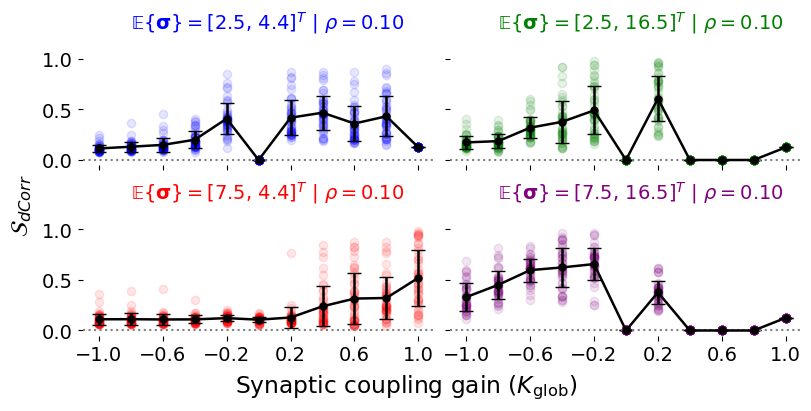

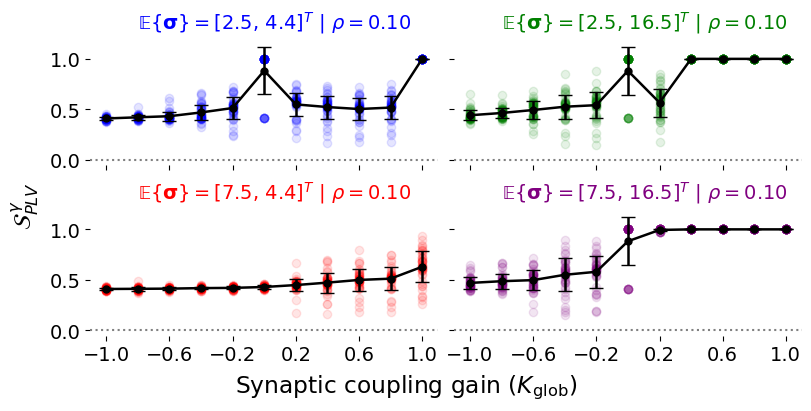

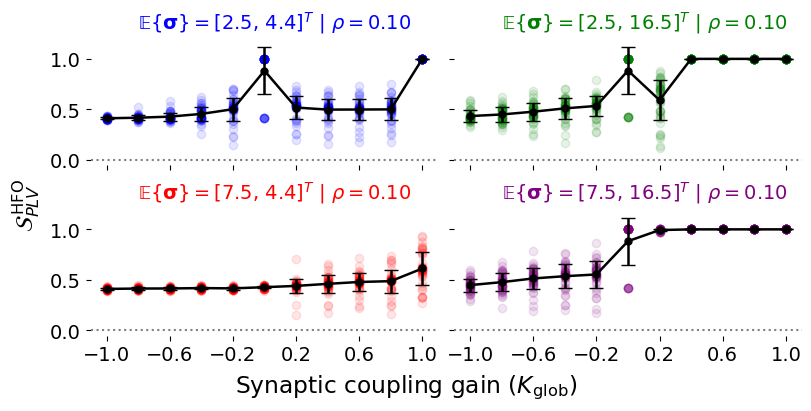

No. of files = 11
No. of files = 11


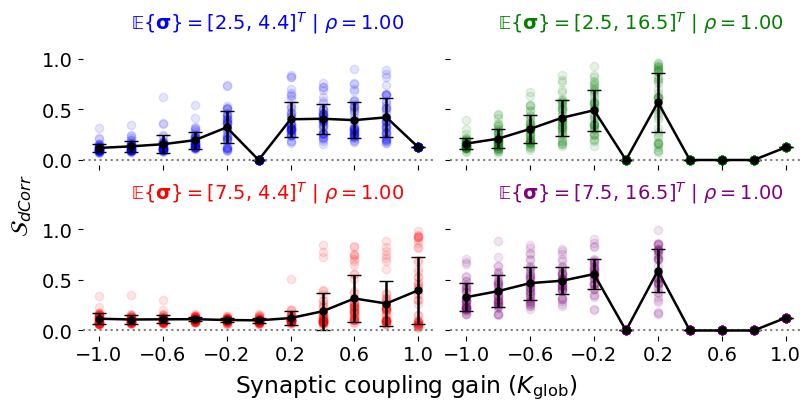

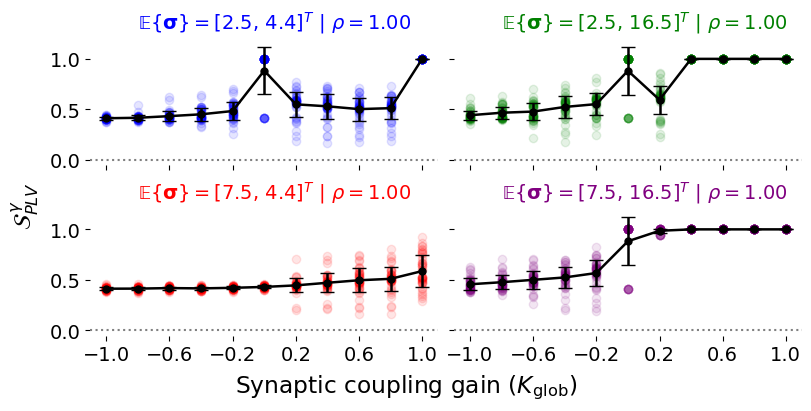

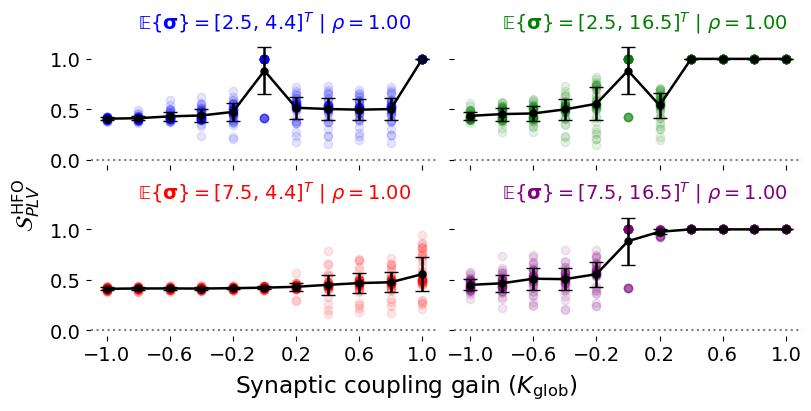

No. of files = 11
No. of files = 11


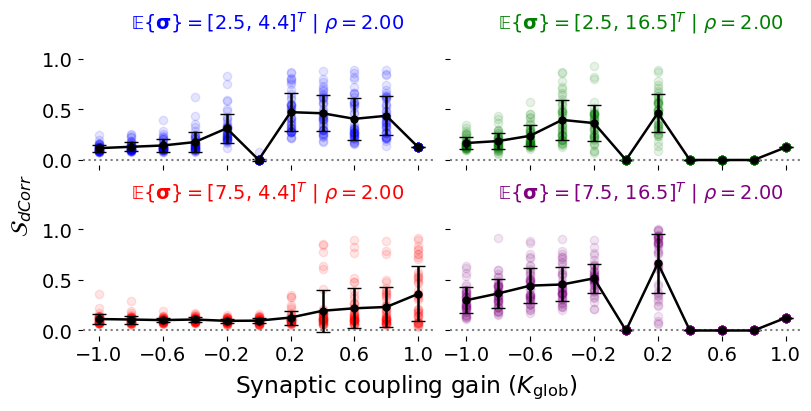

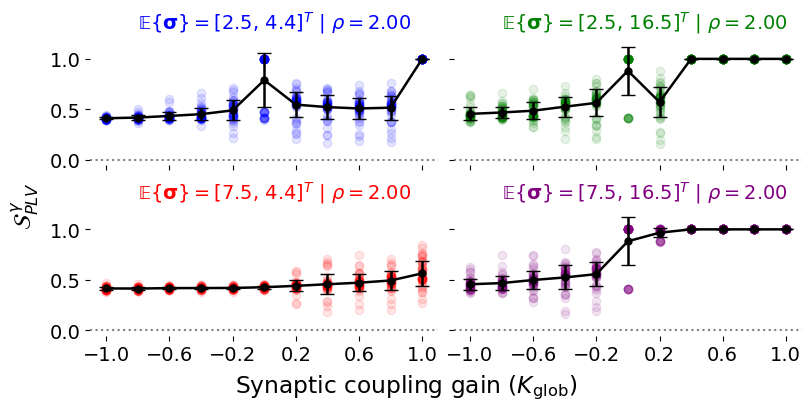

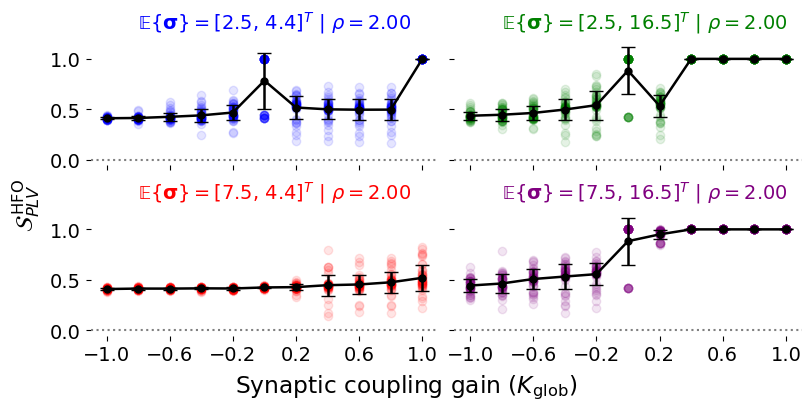

In [29]:
Xlabel = r"Synaptic coupling gain $(K_{\rm glob})$"

for rho in sigVar:
    params["rho"] = rho
    _filedictA, Karr = get_kfiles(loaddir = loadA, seArr = sigeArr, siArr = sigiArr, **params)
    fweightdist(_filedict = _filedictA, _sigeArr = sigeArr, _sigiArr = sigiArr, Xarr = Karr, Xlabel=Xlabel, M=1, figroot = figurerootA, **params)
    # degreeNodes(_filedict=_filedictA, _sigeArr=sigeArr, _sigiArr=sigiArr, Xarr=Karr, offset = 0.1,  Xlabel=Xlabel, M=1, figroot=figurerootA, **params)


In [14]:
rootAR = "Setup_A3"
volatile_dir = "results/functionality"

save_str = datetime.datetime(2024, 4, 5)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadAR = os.path.join("../", rootAR, volatile_dir, sub_dir)

_filedictAR, Karr = _get_kfiles(loaddir = loadAR, seArr = sigeArr, siArr = sigiArr, **params)

No. of files = 11
No. of files = 11
No. of files = 11
No. of files = 11


No. of files = 11
No. of files = 11
No. of files = 11
No. of files = 11
No. of files = 11
No. of files = 11
[[0.         0.25570153 0.21058471 0.17513215 0.26596944 0.24095613
  0.32709972 0.26533629 0.22912998 0.3413038 ]
 [0.25570153 0.         0.83540463 0.76254714 0.6080107  0.57662625
  0.44880703 0.41214036 0.62808741 0.26808047]
 [0.21058471 0.83540463 0.         0.64975553 0.4876021  0.46163381
  0.2591668  0.24373454 0.53421787 0.28254064]
 [0.17513215 0.76254714 0.64975553 0.         0.55974887 0.66238686
  0.34726809 0.49795031 0.60986948 0.40973652]
 [0.26596944 0.6080107  0.4876021  0.55974887 0.         0.45264688
  0.4534373  0.53975062 0.69480308 0.28848946]
 [0.24095613 0.57662625 0.46163381 0.66238686 0.45264688 0.
  0.35868711 0.34101147 0.26136487 0.36767001]
 [0.32709972 0.44880703 0.2591668  0.34726809 0.4534373  0.35868711
  0.         0.49804599 0.46199542 0.41924847]
 [0.26533629 0.41214036 0.24373454 0.49795031 0.53975062 0.34101147
  0.49804599 0.         0.7

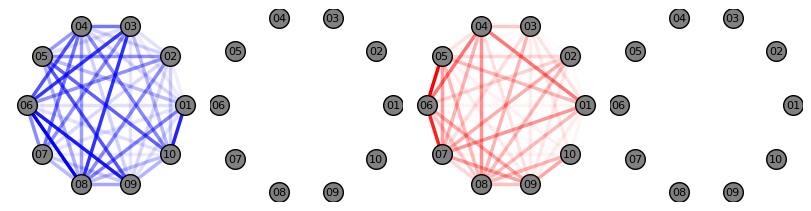

[[0.         0.25570153 0.21058471 0.17513215 0.26596944 0.24095613
  0.32709972 0.26533629 0.22912998 0.3413038 ]
 [0.25570153 0.         0.83540463 0.76254714 0.6080107  0.57662625
  0.44880703 0.41214036 0.62808741 0.26808047]
 [0.21058471 0.83540463 0.         0.64975553 0.4876021  0.46163381
  0.2591668  0.24373454 0.53421787 0.28254064]
 [0.17513215 0.76254714 0.64975553 0.         0.55974887 0.66238686
  0.34726809 0.49795031 0.60986948 0.40973652]
 [0.26596944 0.6080107  0.4876021  0.55974887 0.         0.45264688
  0.4534373  0.53975062 0.69480308 0.28848946]
 [0.24095613 0.57662625 0.46163381 0.66238686 0.45264688 0.
  0.35868711 0.34101147 0.26136487 0.36767001]
 [0.32709972 0.44880703 0.2591668  0.34726809 0.4534373  0.35868711
  0.         0.49804599 0.46199542 0.41924847]
 [0.26533629 0.41214036 0.24373454 0.49795031 0.53975062 0.34101147
  0.49804599 0.         0.7819116  0.38498027]
 [0.22912998 0.62808741 0.53421787 0.60986948 0.69480308 0.26136487
  0.46199542 0.78191

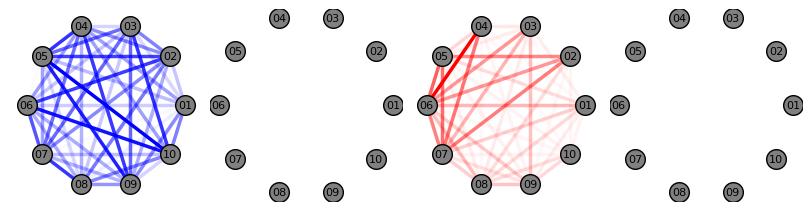

[[0.         0.25570153 0.21058471 0.17513215 0.26596944 0.24095613
  0.32709972 0.26533629 0.22912998 0.3413038 ]
 [0.25570153 0.         0.83540463 0.76254714 0.6080107  0.57662625
  0.44880703 0.41214036 0.62808741 0.26808047]
 [0.21058471 0.83540463 0.         0.64975553 0.4876021  0.46163381
  0.2591668  0.24373454 0.53421787 0.28254064]
 [0.17513215 0.76254714 0.64975553 0.         0.55974887 0.66238686
  0.34726809 0.49795031 0.60986948 0.40973652]
 [0.26596944 0.6080107  0.4876021  0.55974887 0.         0.45264688
  0.4534373  0.53975062 0.69480308 0.28848946]
 [0.24095613 0.57662625 0.46163381 0.66238686 0.45264688 0.
  0.35868711 0.34101147 0.26136487 0.36767001]
 [0.32709972 0.44880703 0.2591668  0.34726809 0.4534373  0.35868711
  0.         0.49804599 0.46199542 0.41924847]
 [0.26533629 0.41214036 0.24373454 0.49795031 0.53975062 0.34101147
  0.49804599 0.         0.7819116  0.38498027]
 [0.22912998 0.62808741 0.53421787 0.60986948 0.69480308 0.26136487
  0.46199542 0.78191

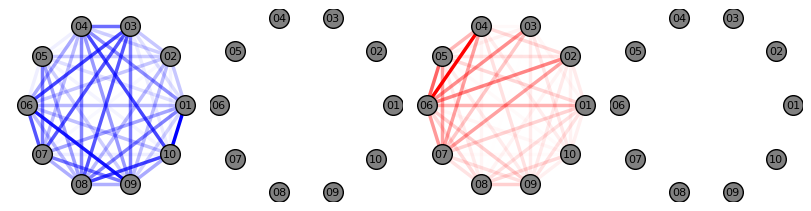

[[0.         0.16462842 0.2685857  0.2573721  0.38962161 0.34547603
  0.43002097 0.3803205  0.36391933 0.39403642]
 [0.16462842 0.         0.69694122 0.68066131 0.56029543 0.58642005
  0.49135597 0.56919178 0.56222043 0.52089303]
 [0.2685857  0.69694122 0.         0.64911203 0.56939338 0.53553579
  0.52378723 0.5396907  0.55325403 0.53981354]
 [0.2573721  0.68066131 0.64911203 0.         0.58114298 0.67009385
  0.55167664 0.64236727 0.58168009 0.55956793]
 [0.38962161 0.56029543 0.56939338 0.58114298 0.         0.56417778
  0.58888095 0.52252149 0.57209763 0.53703716]
 [0.34547603 0.58642005 0.53553579 0.67009385 0.56417778 0.
  0.53110332 0.56591655 0.52918827 0.53200232]
 [0.43002097 0.49135597 0.52378723 0.55167664 0.58888095 0.53110332
  0.         0.53834894 0.57486401 0.55648546]
 [0.3803205  0.56919178 0.5396907  0.64236727 0.52252149 0.56591655
  0.53834894 0.         0.65667638 0.59606728]
 [0.36391933 0.56222043 0.55325403 0.58168009 0.57209763 0.52918827
  0.57486401 0.65667

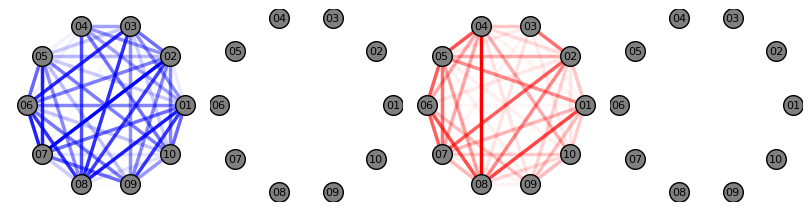

[[0.         0.16462842 0.2685857  0.2573721  0.38962161 0.34547603
  0.43002097 0.3803205  0.36391933 0.39403642]
 [0.16462842 0.         0.69694122 0.68066131 0.56029543 0.58642005
  0.49135597 0.56919178 0.56222043 0.52089303]
 [0.2685857  0.69694122 0.         0.64911203 0.56939338 0.53553579
  0.52378723 0.5396907  0.55325403 0.53981354]
 [0.2573721  0.68066131 0.64911203 0.         0.58114298 0.67009385
  0.55167664 0.64236727 0.58168009 0.55956793]
 [0.38962161 0.56029543 0.56939338 0.58114298 0.         0.56417778
  0.58888095 0.52252149 0.57209763 0.53703716]
 [0.34547603 0.58642005 0.53553579 0.67009385 0.56417778 0.
  0.53110332 0.56591655 0.52918827 0.53200232]
 [0.43002097 0.49135597 0.52378723 0.55167664 0.58888095 0.53110332
  0.         0.53834894 0.57486401 0.55648546]
 [0.3803205  0.56919178 0.5396907  0.64236727 0.52252149 0.56591655
  0.53834894 0.         0.65667638 0.59606728]
 [0.36391933 0.56222043 0.55325403 0.58168009 0.57209763 0.52918827
  0.57486401 0.65667

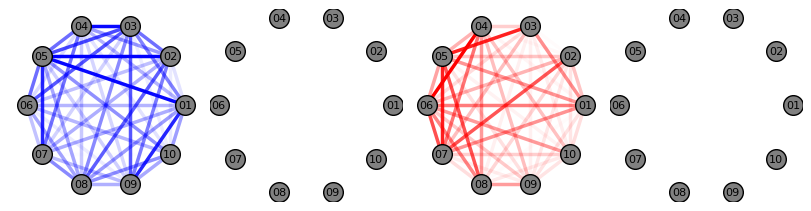

[[0.         0.16462842 0.2685857  0.2573721  0.38962161 0.34547603
  0.43002097 0.3803205  0.36391933 0.39403642]
 [0.16462842 0.         0.69694122 0.68066131 0.56029543 0.58642005
  0.49135597 0.56919178 0.56222043 0.52089303]
 [0.2685857  0.69694122 0.         0.64911203 0.56939338 0.53553579
  0.52378723 0.5396907  0.55325403 0.53981354]
 [0.2573721  0.68066131 0.64911203 0.         0.58114298 0.67009385
  0.55167664 0.64236727 0.58168009 0.55956793]
 [0.38962161 0.56029543 0.56939338 0.58114298 0.         0.56417778
  0.58888095 0.52252149 0.57209763 0.53703716]
 [0.34547603 0.58642005 0.53553579 0.67009385 0.56417778 0.
  0.53110332 0.56591655 0.52918827 0.53200232]
 [0.43002097 0.49135597 0.52378723 0.55167664 0.58888095 0.53110332
  0.         0.53834894 0.57486401 0.55648546]
 [0.3803205  0.56919178 0.5396907  0.64236727 0.52252149 0.56591655
  0.53834894 0.         0.65667638 0.59606728]
 [0.36391933 0.56222043 0.55325403 0.58168009 0.57209763 0.52918827
  0.57486401 0.65667

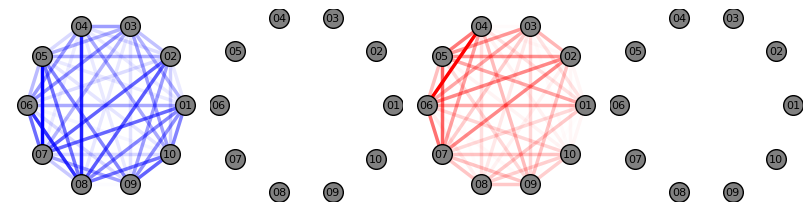

[[0.         0.17723562 0.25073043 0.26836922 0.37512358 0.35176089
  0.38962988 0.39483028 0.36917367 0.41750106]
 [0.17723562 0.         0.70277524 0.65691439 0.55235385 0.54295776
  0.53776774 0.51921609 0.55140533 0.50454809]
 [0.25073043 0.70277524 0.         0.62301185 0.5353305  0.52977394
  0.5218895  0.49876276 0.52053886 0.49858287]
 [0.26836922 0.65691439 0.62301185 0.         0.53167509 0.61071783
  0.50799524 0.58882043 0.57110376 0.53274493]
 [0.37512358 0.55235385 0.5353305  0.53167509 0.         0.48458834
  0.54377928 0.52645013 0.54257838 0.53965643]
 [0.35176089 0.54295776 0.52977394 0.61071783 0.48458834 0.
  0.51155665 0.52182987 0.50119266 0.55254735]
 [0.38962988 0.53776774 0.5218895  0.50799524 0.54377928 0.51155665
  0.         0.50524213 0.5195449  0.5216699 ]
 [0.39483028 0.51921609 0.49876276 0.58882043 0.52645013 0.52182987
  0.50524213 0.         0.67026304 0.53313932]
 [0.36917367 0.55140533 0.52053886 0.57110376 0.54257838 0.50119266
  0.5195449  0.67026

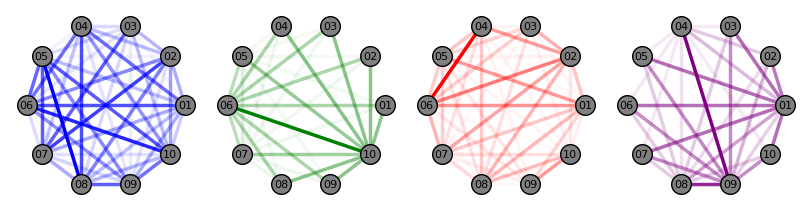

[[0.         0.17723562 0.25073043 0.26836922 0.37512358 0.35176089
  0.38962988 0.39483028 0.36917367 0.41750106]
 [0.17723562 0.         0.70277524 0.65691439 0.55235385 0.54295776
  0.53776774 0.51921609 0.55140533 0.50454809]
 [0.25073043 0.70277524 0.         0.62301185 0.5353305  0.52977394
  0.5218895  0.49876276 0.52053886 0.49858287]
 [0.26836922 0.65691439 0.62301185 0.         0.53167509 0.61071783
  0.50799524 0.58882043 0.57110376 0.53274493]
 [0.37512358 0.55235385 0.5353305  0.53167509 0.         0.48458834
  0.54377928 0.52645013 0.54257838 0.53965643]
 [0.35176089 0.54295776 0.52977394 0.61071783 0.48458834 0.
  0.51155665 0.52182987 0.50119266 0.55254735]
 [0.38962988 0.53776774 0.5218895  0.50799524 0.54377928 0.51155665
  0.         0.50524213 0.5195449  0.5216699 ]
 [0.39483028 0.51921609 0.49876276 0.58882043 0.52645013 0.52182987
  0.50524213 0.         0.67026304 0.53313932]
 [0.36917367 0.55140533 0.52053886 0.57110376 0.54257838 0.50119266
  0.5195449  0.67026

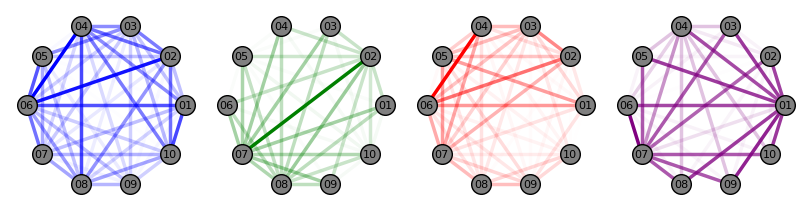

[[0.         0.17723562 0.25073043 0.26836922 0.37512358 0.35176089
  0.38962988 0.39483028 0.36917367 0.41750106]
 [0.17723562 0.         0.70277524 0.65691439 0.55235385 0.54295776
  0.53776774 0.51921609 0.55140533 0.50454809]
 [0.25073043 0.70277524 0.         0.62301185 0.5353305  0.52977394
  0.5218895  0.49876276 0.52053886 0.49858287]
 [0.26836922 0.65691439 0.62301185 0.         0.53167509 0.61071783
  0.50799524 0.58882043 0.57110376 0.53274493]
 [0.37512358 0.55235385 0.5353305  0.53167509 0.         0.48458834
  0.54377928 0.52645013 0.54257838 0.53965643]
 [0.35176089 0.54295776 0.52977394 0.61071783 0.48458834 0.
  0.51155665 0.52182987 0.50119266 0.55254735]
 [0.38962988 0.53776774 0.5218895  0.50799524 0.54377928 0.51155665
  0.         0.50524213 0.5195449  0.5216699 ]
 [0.39483028 0.51921609 0.49876276 0.58882043 0.52645013 0.52182987
  0.50524213 0.         0.67026304 0.53313932]
 [0.36917367 0.55140533 0.52053886 0.57110376 0.54257838 0.50119266
  0.5195449  0.67026

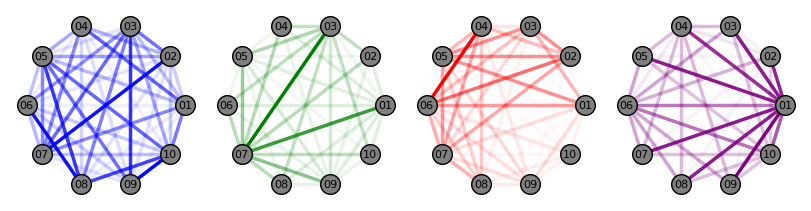

In [28]:
rhoFilesA = {}
for rho in sigVar:
    params["rho"] = rho
    _filedictA, Karr = get_kfiles(loaddir = loadA, seArr = sigeArr, siArr = sigiArr, **params)
    rhoFilesA[rho] = _filedictA

# deltaMeasure(
#              _rhofiles=rhoFilesA, 
#              _basefiles=_filedictAR, 
#              sigVar=sigVar, 
#              _sigeArr=sigeArr, 
#              _sigiArr=sigiArr, 
#              M=1, 
#              figroot=figurerootA, 
#              _Kind = 7, 
#              **params
#              )
deltfweightdist(
                _rhofiles=rhoFilesA, 
                _basefiles=_filedictAR, 
                sigVar=sigVar, 
                _sigeArr=sigeArr, 
                _sigiArr=sigiArr, 
                Xarr=Karr, 
                Xlabel=Xlabel, 
                figroot=figurerootA, 
                M = 1, 
                **params
                )

In [16]:
rootB = "Setup_B3v"
volatile_dir = "results/functionality"

save_str = datetime.datetime(2024, 4, 5)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadB = os.path.join("../", rootB, volatile_dir, sub_dir)

figurerootB = "./results/functionality/ConfigureBv"
os.makedirs(figurerootB, exist_ok=True)

In [17]:
Xlabel = r"Synaptic coupling gain $(K_{\rm glob})$"

# for rho in sigVar:
#     params["rho"] = rho
#     _filedictB, Karr = get_kfiles(loaddir = loadB, seArr = sigeArr, siArr = sigiArr, **params)
#     fweightdist(_filedict=_filedictB, _sigeArr=sigeArr, _sigiArr=sigiArr, Xarr=Karr, Xlabel=Xlabel, M=0, figroot = figurerootB, **params)
#     degreeNodes(_filedict=_filedictB, _sigeArr=sigeArr, _sigiArr=sigiArr, Xarr=Karr, offset = 0.1,  Xlabel=Xlabel, M=0, figroot=figurerootB, **params)


In [18]:
rootBR = "Setup_B3"
volatile_dir = "results/functionality"

save_str = datetime.datetime(2024, 4, 5)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadBR = os.path.join("../", rootBR, volatile_dir, sub_dir)

_filedictBR, Karr = _get_kfiles(loaddir = loadBR, seArr = sigeArr, siArr = sigiArr, **params)

No. of files = 11
No. of files = 11
No. of files = 11
No. of files = 11


No. of files = 11
No. of files = 11
No. of files = 11
No. of files = 11
No. of files = 11
No. of files = 11


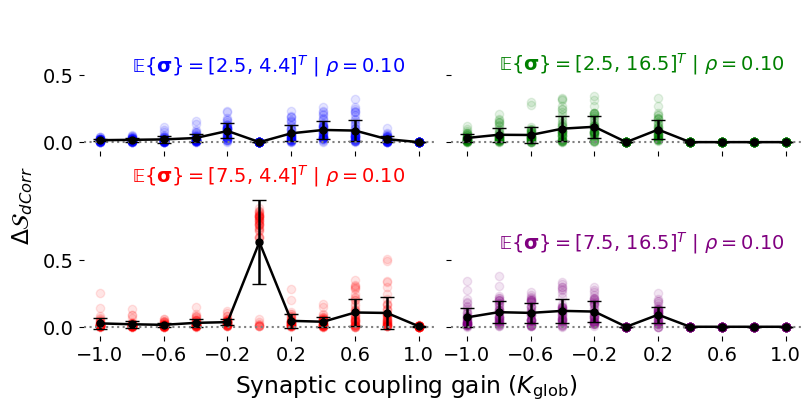

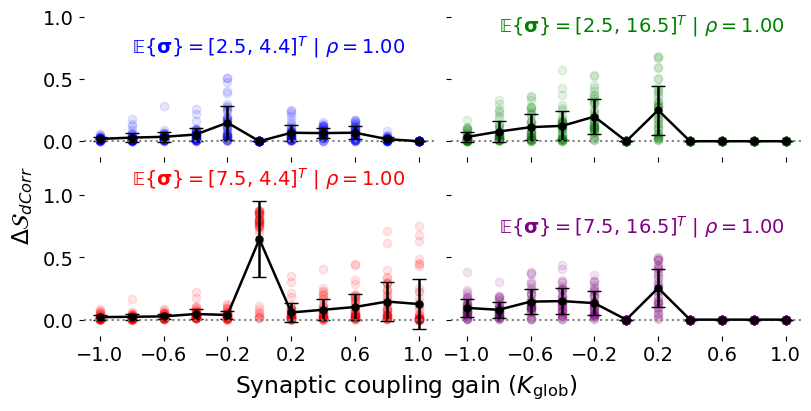

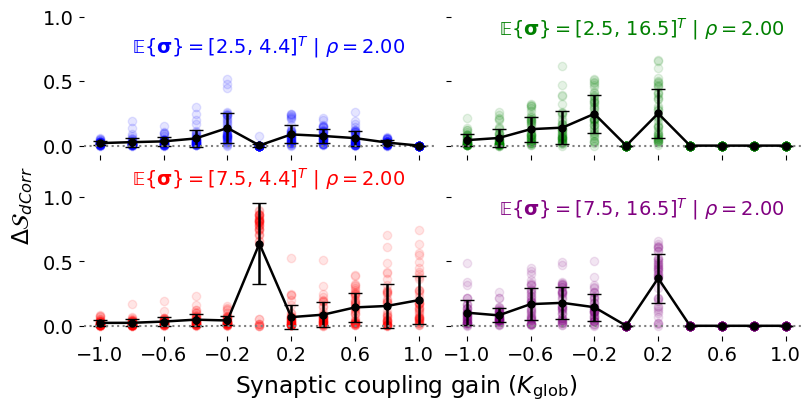

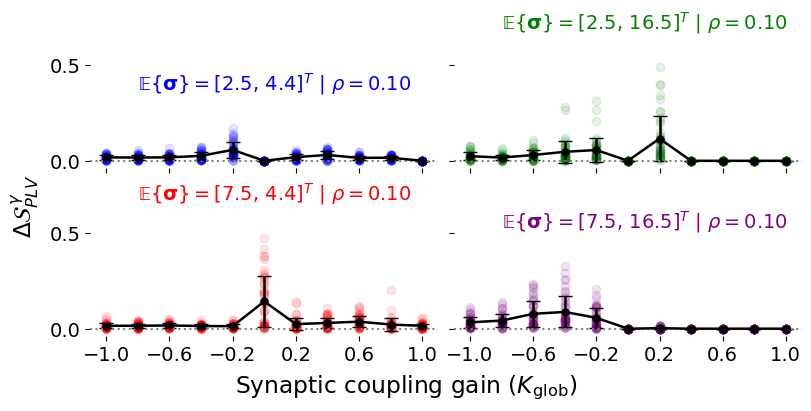

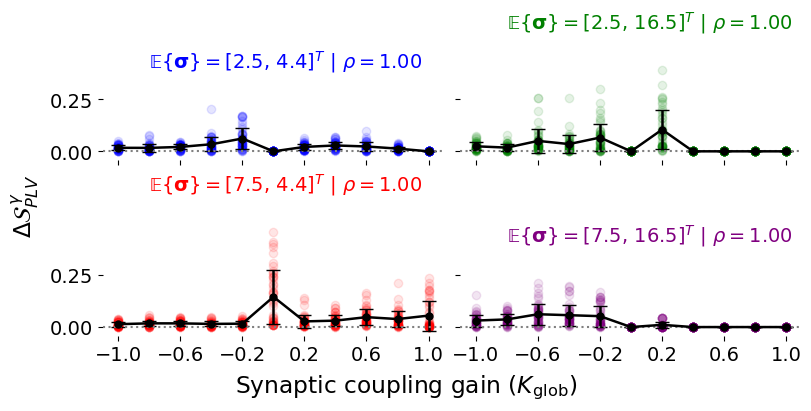

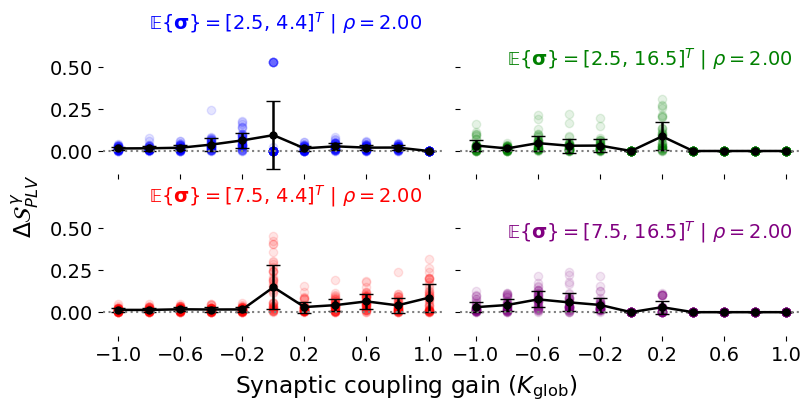

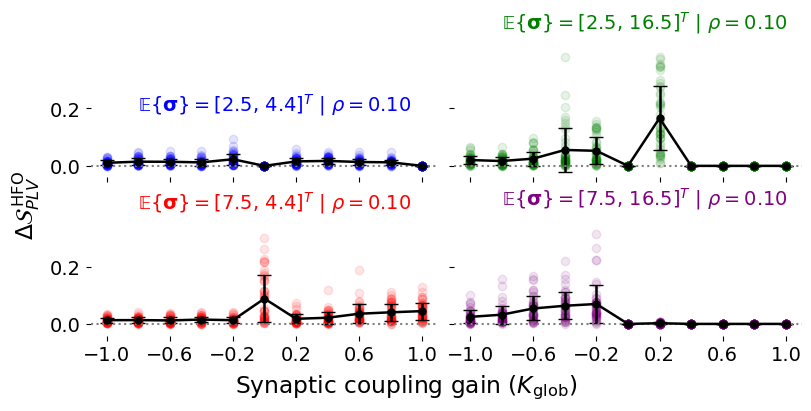

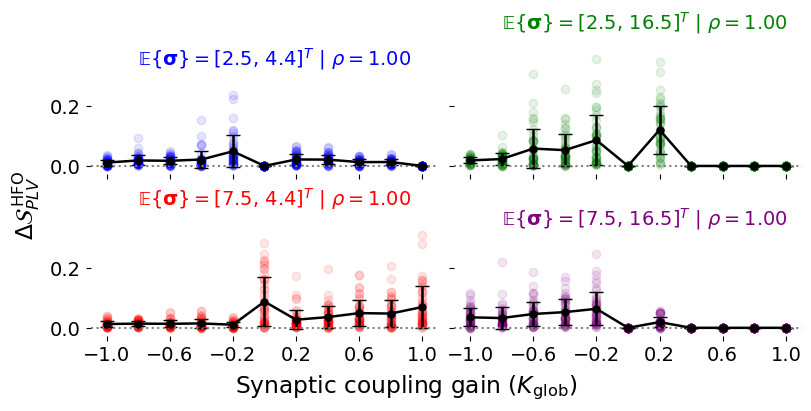

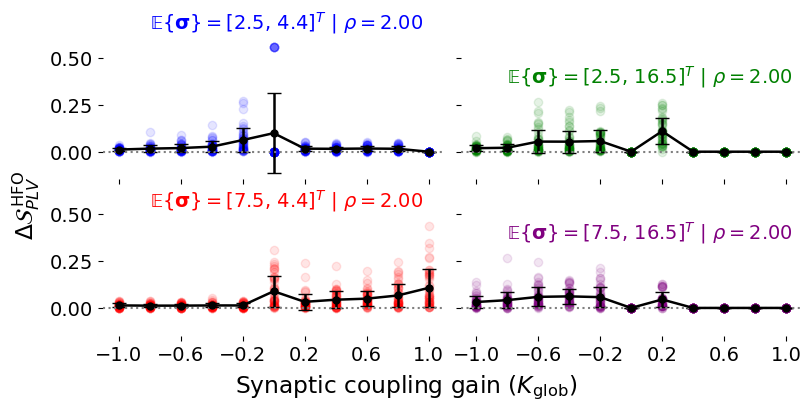

In [27]:
rhoFilesB = {}
for rho in sigVar:
    params["rho"] = rho
    _filedictB, Karr = get_kfiles(loaddir = loadB, seArr = sigeArr, siArr = sigiArr, **params)
    rhoFilesB[rho] = _filedictB

# deltaMeasure(
#              _rhofiles=rhoFilesB, 
#              _basefiles=_filedictBR, 
#              sigVar=sigVar, 
#              _sigeArr=sigeArr, 
#              _sigiArr=sigiArr, 
#              M=0, 
#              figroot=figurerootB, 
#              _Kind = 7, 
#              **params
#              )
deltfweightdist(
                _rhofiles=rhoFilesA, 
                _basefiles=_filedictAR, 
                sigVar=sigVar, 
                _sigeArr=sigeArr, 
                _sigiArr=sigiArr, 
                Xarr=Karr, 
                Xlabel=Xlabel, 
                figroot=figurerootA, 
                M = 1, 
                **params
                )